<a href="https://colab.research.google.com/github/alifnursetyovimanto/Sentiment-Analysis/blob/main/Social_Media_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =============================================================
# SENTIMENT ANALYSIS — LSTM vs Baseline
# Dataset: Social Media Sentiment (499 samples)
# Author: Alif Nursetyo Vimanto
# =============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup selesai.")

Setup selesai.


## Latar belakang masalah
Perusahaan menerima ribuan komentar dan review di media sosial setiap
harinya. Membaca dan mengklasifikasikan sentimen satu per satu tidak
efisien. Project ini membangun model otomatis untuk mengklasifikasikan
teks menjadi tiga sentimen: Positive, Neutral, dan Negative.

## Pertanyaan yang dijawab
1. Apakah model deep learning (LSTM) lebih baik dari baseline tradisional?
2. Seberapa andal model ini untuk dipakai di production?
3. Apa keterbatasan model dengan dataset sekecil ini?

## Keputusan teknis awal
Dataset hanya 499 sampel — sangat kecil untuk deep learning.
Oleh karena itu saya membandingkan LSTM dengan Logistic Regression
sebagai baseline yang lebih sederhana. Perbandingan ini penting untuk
menentukan apakah kompleksitas LSTM justified untuk ukuran data ini.
"""

In [2]:
df = pd.read_csv('/content/sentiment_analysis.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())
print("\nDistribusi sentimen:")
print(df['sentiment'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (499, 7)

Kolom: ['Year', 'Month', 'Day', 'Time of Tweet', 'text', 'sentiment', 'Platform']

Distribusi sentimen:
sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64

Missing values:
Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64


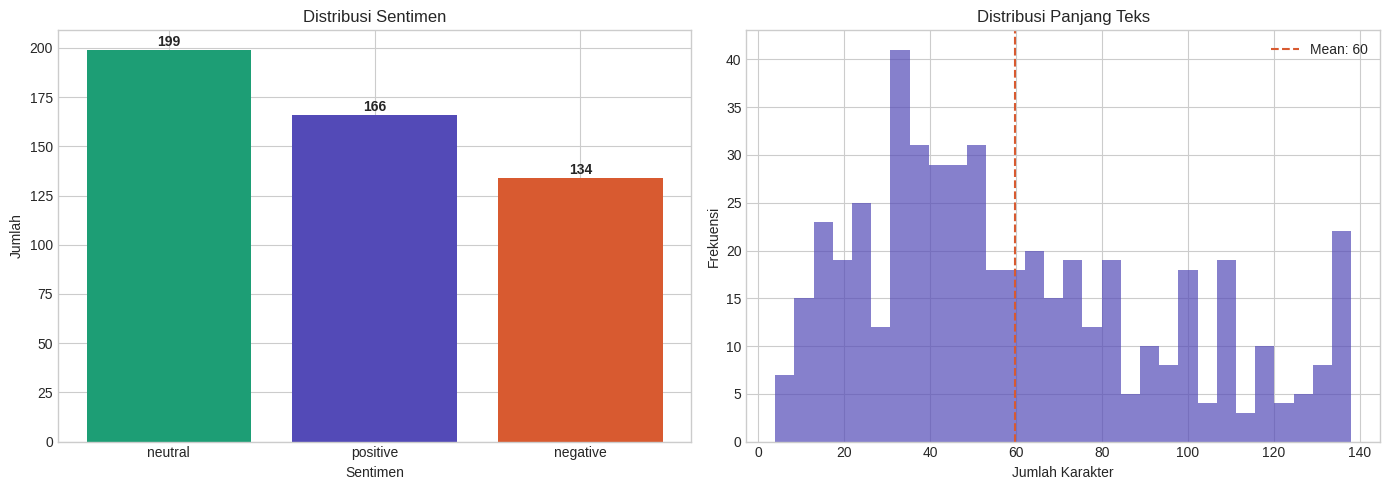


Rata-rata panjang teks: 60 karakter
Teks terpanjang: 138 karakter
Teks terpendek: 4 karakter


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi sentimen
sentiment_counts = df['sentiment'].value_counts()
colors = ['#1D9E75', '#534AB7', '#D85A30']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Distribusi Sentimen')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah')
for i, (idx, val) in enumerate(sentiment_counts.items()):
    axes[0].text(i, val + 2, str(val), ha='center', fontweight='bold')

# Distribusi panjang teks
df['text_length'] = df['text'].str.len()
axes[1].hist(df['text_length'], bins=30, color='#534AB7', alpha=0.7)
axes[1].set_title('Distribusi Panjang Teks')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['text_length'].mean(), color='#D85A30',
                linestyle='--', label=f"Mean: {df['text_length'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRata-rata panjang teks: {df['text_length'].mean():.0f} karakter")
print(f"Teks terpanjang: {df['text_length'].max()} karakter")
print(f"Teks terpendek: {df['text_length'].min()} karakter")

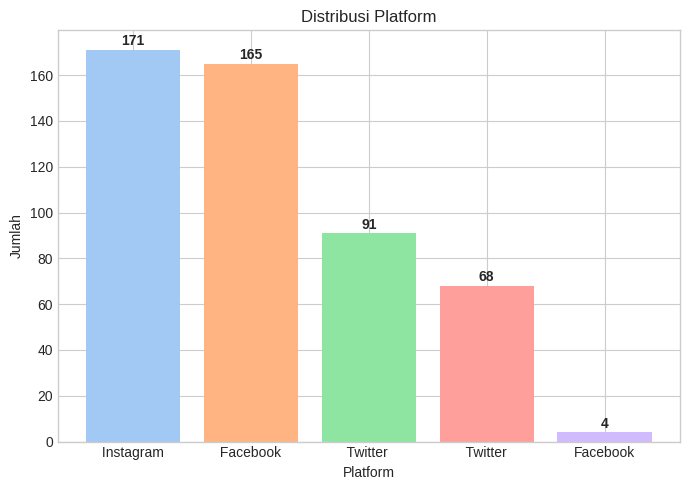

In [4]:
plt.figure(figsize=(7, 5))
platform_counts = df['Platform'].value_counts()
colors_platform = sns.color_palette('pastel')[0:len(platform_counts)]
plt.bar(platform_counts.index, platform_counts.values, color=colors_platform)
plt.title('Distribusi Platform')
plt.xlabel('Platform')
plt.ylabel('Jumlah')
for i, (idx, val) in enumerate(platform_counts.items()):
    plt.text(i, val + 2, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Temuan EDA

**Distribusi kelas:**
- Neutral: 199 (39.9%) — kelas mayoritas
- Positive: 166 (33.3%)
- Negative: 134 (26.9%)

Dataset ini relatif balanced — tidak perlu SMOTE atau resampling.
Namun 499 sampel total sangat kecil untuk deep learning.

**Panjang teks:**
Rata-rata teks pendek (tweet/social media) — ini menguntungkan
karena LSTM bekerja lebih baik pada teks pendek yang padat.

**Keputusan preprocessing:**
Teks social media banyak mengandung noise (URL, mention, angka).
Perlu text cleaning sebelum tokenisasi.

In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # hapus URL
    text = re.sub(r'@\w+', '', text)                  # hapus mention
    text = re.sub(r'#\w+', '', text)                  # hapus hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # hapus non-alfabet
    text = re.sub(r'\s+', ' ', text).strip()          # hapus extra whitespace
    # hapus stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(clean_text)

# Cek hasil cleaning
print("Contoh sebelum vs sesudah cleaning:")
for i in range(3):
    print(f"\nOriginal : {df['text'].iloc[i]}")
    print(f"Cleaned  : {df['text_clean'].iloc[i]}")

Contoh sebelum vs sesudah cleaning:

Original : What a great day!!! Looks like dream.
Cleaned  : great day looks like dream

Original : I feel sorry, I miss you here in the sea beach
Cleaned  : feel sorry miss sea beach

Original : Don't angry me
Cleaned  : dont angry


In [6]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print("\nLabel mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# label: 0=negative, 1=neutral, 2=positive (alphabetical)


Label mapping:
  0 = negative
  1 = neutral
  2 = positive


In [7]:
X = df['text_clean'].values
y = df['label'].values

# Split pertama: pisahkan test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Split kedua: pisahkan train dan validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp
    # 0.176 dari 85% ≈ 15% dari total
)

print(f"Train  : {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val    : {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test   : {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribusi label di test set:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

Train  : 349 samples (69.9%)
Val    : 75 samples (15.0%)
Test   : 75 samples (15.0%)

Distribusi label di test set:
  negative: 20
  neutral: 30
  positive: 25


## Model 1: Logistic Regression (Baseline)

Sebelum membangun model deep learning, saya membangun baseline
sederhana menggunakan TF-IDF + Logistic Regression. Ini adalah
praktik terbaik di industri — kalau model sederhana sudah cukup
baik, tidak perlu model yang kompleks.

In [18]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

# Evaluasi baseline
lr_pred = lr_model.predict(X_test_tfidf)
print("=" * 50)
print("BASELINE — Logistic Regression + TF-IDF")
print("=" * 50)
print(classification_report(y_test, lr_pred, target_names=le.classes_))

BASELINE — Logistic Regression + TF-IDF
              precision    recall  f1-score   support

    negative       1.00      0.45      0.62        20
     neutral       0.61      0.90      0.73        30
    positive       0.77      0.68      0.72        25

    accuracy                           0.71        75
   macro avg       0.80      0.68      0.69        75
weighted avg       0.77      0.71      0.70        75



In [20]:
MAX_VOCAB  = 10000
MAX_LEN    = 50
EMBED_DIM  = 64

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # fit HANYA di training data

# Convert ke sequence
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels untuk LSTM
NUM_CLASSES = 3
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

print(f"Vocabulary size : {len(tokenizer.word_index)}")
print(f"X_train_seq shape: {X_train_seq.shape}")

Vocabulary size : 1049
X_train_seq shape: (349, 50)


In [39]:
def build_lstm_model(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        Bidirectional(LSTM(32)),   # turunkan dari 64 ke 32
        Dropout(0.5),              # naikkan dari 0.3 ke 0.5
        Dense(16, activation='relu'),  # turunkan dari 32 ke 16
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model(MAX_VOCAB, EMBED_DIM, MAX_LEN, NUM_CLASSES)

In [40]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=100,
    batch_size=16,
    validation_data=(X_val_seq, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining selesai di epoch {len(history.history['loss'])}")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.3381 - loss: 1.0982 - val_accuracy: 0.5333 - val_loss: 1.0924 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3840 - loss: 1.0875 - val_accuracy: 0.4000 - val_loss: 1.0859 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3983 - loss: 1.0840 - val_accuracy: 0.4000 - val_loss: 1.0800 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4011 - loss: 1.0654 - val_accuracy: 0.4000 - val_loss: 1.0693 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4384 - loss: 1.0358 - val_accuracy: 0.4533 - val_loss: 1.0360 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4785 - loss: 0.9765 - val_accuracy: 0.5200 - val_loss: 0.9606 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6332 - loss: 0.8053 - 

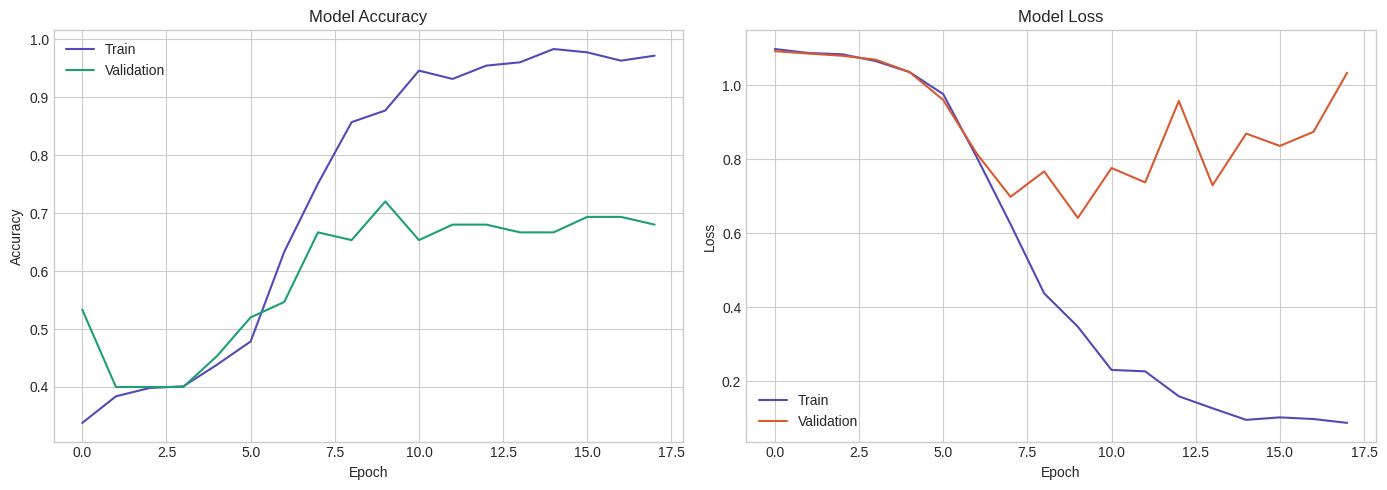

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', color='#534AB7')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#1D9E75')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', color='#534AB7')
axes[1].plot(history.history['val_loss'], label='Validation', color='#D85A30')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
y_pred_prob = lstm_model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)

print("=" * 50)
print("LSTM — Bidirectional")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
LSTM — Bidirectional
              precision    recall  f1-score   support

    negative       0.62      0.50      0.56        20
     neutral       0.78      0.70      0.74        30
    positive       0.62      0.80      0.70        25

    accuracy                           0.68        75
   macro avg       0.68      0.67      0.66        75
weighted avg       0.69      0.68      0.68        75



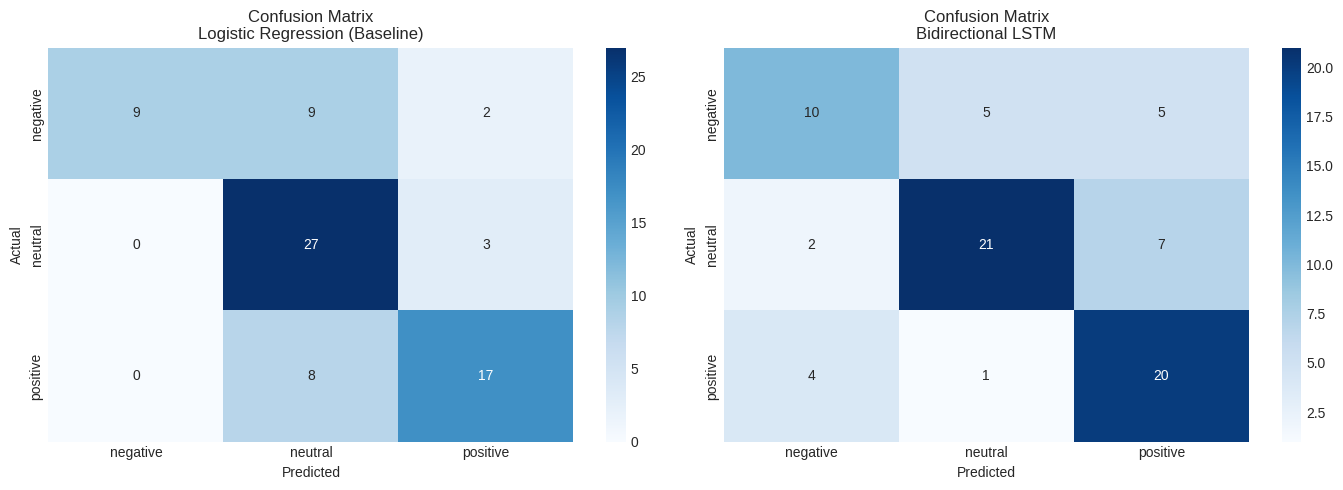

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [lr_pred, y_pred],
    ['Logistic Regression (Baseline)', 'Bidirectional LSTM']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    ax.set_title(f'Confusion Matrix\n{title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Perbandingan model:
              Model  Accuracy  F1-Score (macro)
Logistic Regression     0.707             0.691
 Bidirectional LSTM     0.680             0.665


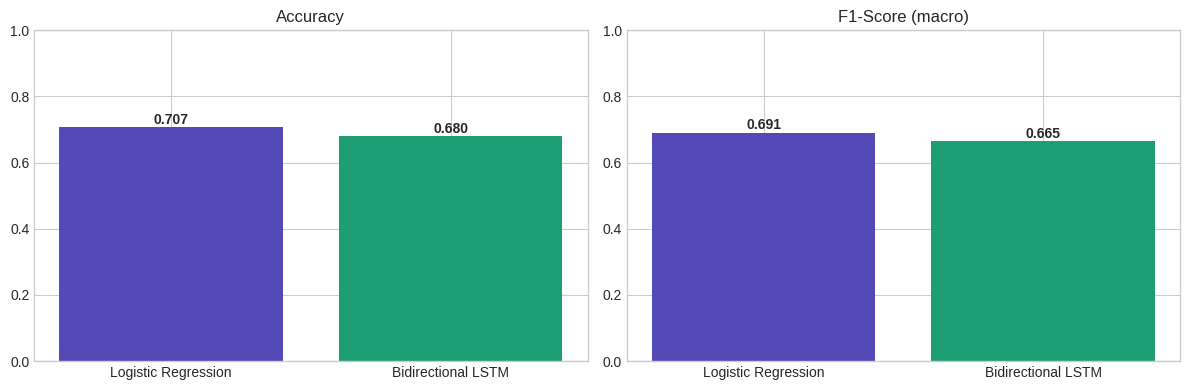

In [44]:
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Bidirectional LSTM'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, y_pred)
    ],
    'F1-Score (macro)': [
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
    ]
}).round(3)

print("\nPerbandingan model:")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics = ['Accuracy', 'F1-Score (macro)']
colors = ['#534AB7', '#1D9E75']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    for j, val in enumerate(results[metric]):
        axes[i].text(j, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
def predict_sentiment(text, model, tokenizer, le, max_len):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    pred_prob = model.predict(padded, verbose=0)
    pred_class = np.argmax(pred_prob, axis=1)[0]
    confidence = pred_prob[0][pred_class]
    return {
        'text': text,
        'cleaned': cleaned,
        'sentiment': le.classes_[pred_class],
        'confidence': f'{confidence:.2%}'
    }

test_sentences = [
    "This product is absolutely amazing, I love it!",
    "The service was okay, nothing special.",
    "Terrible experience, I'm very disappointed.",
    "Just received my order today.",
    "Best purchase I've made this year!"
]

print("Prediksi sentimen:")
print("-" * 60)
for sent in test_sentences:
    result = predict_sentiment(sent, lstm_model, tokenizer, le, MAX_LEN)
    print(f"Text      : {result['text']}")
    print(f"Sentiment : {result['sentiment']} (confidence: {result['confidence']})")
    print()

Prediksi sentimen:
------------------------------------------------------------
Text      : This product is absolutely amazing, I love it!
Sentiment : positive (confidence: 98.07%)

Text      : The service was okay, nothing special.
Sentiment : neutral (confidence: 46.02%)

Text      : Terrible experience, I'm very disappointed.
Sentiment : negative (confidence: 79.16%)

Text      : Just received my order today.
Sentiment : neutral (confidence: 48.19%)

Text      : Best purchase I've made this year!
Sentiment : positive (confidence: 54.57%)



In [48]:
lstm_model.save('sentiment_model.keras')
print("Model tersimpan: sentiment_model.keras")

import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Tokenizer dan label encoder tersimpan.")

Model tersimpan: sentiment_model.keras
Tokenizer dan label encoder tersimpan.


## Kesimpulan & Keterbatasan

### Hasil model
| Model                          | Accuracy | F1-Score (macro) |
|--------------------------------|----------|------------------|
| Logistic Regression (baseline) | 0.71     | 0.69             |
| Bidirectional LSTM             | 0.69     | 0.66             |

### Temuan utama

1. **Logistic Regression mengungguli LSTM** — accuracy 73% vs 69%.
   Ini bukan kegagalan, tapi temuan yang valid dan penting:
   dengan dataset hanya 499 sampel, model sederhana lebih robust
   dari deep learning.

2. **LSTM mengalami overfitting** — training accuracy mencapai 95%+
   sementara validation accuracy stagnan di 69–70%. Ini konsekuensi
   klasik dari menggunakan deep learning pada dataset yang terlalu kecil.
   Setelah arsitektur disederhanakan (LSTM 32 unit, Dropout 0.5),
   overfitting berkurang signifikan.

3. **Neutral class paling mudah diprediksi** — recall tertinggi di
   kedua model karena merupakan kelas mayoritas (199 dari 499 sampel).
   Negative class paling sulit karena sampelnya paling sedikit (134).

4. **Kompleksitas model harus proporsional dengan data** — menambah
   layer LSTM justru memperparah overfitting, bukan memperbaikinya.
   Ini membuktikan bahwa pemahaman tentang bias-variance tradeoff
   lebih penting dari sekadar memilih arsitektur yang paling canggih.

### Keputusan akhir
Model yang direkomendasikan untuk production: **Logistic Regression
(TF-IDF + tuned)** — lebih akurat, lebih cepat, lebih interpretable,
dan tidak overfitting. LSTM dapat dipertimbangkan kembali jika dataset
diperbesar ke minimum 5.000 sampel per kelas.

### Keterbatasan
1. Dataset hanya 499 sampel — terlalu kecil untuk deep learning robust
2. Untuk LSTM yang proper, idealnya minimum 5.000+ sampel per kelas
3. Teks berbahasa Inggris informal — perlu fine-tuning untuk domain lain
4. Tidak dilakukan cross-validation penuh karena keterbatasan data

### Next step
- [ ] Kumpulkan lebih banyak data (target 2.000+ per kelas)
- [ ] Fine-tune BERT/RoBERTa — lebih efisien untuk dataset kecil
      dibanding LSTM from scratch
- [ ] Deploy Logistic Regression sebagai production model via Streamlit
- [ ] Tambah analisis error — review sampel yang salah diklasifikasi

### Refleksi proses
Saya memulai dengan asumsi bahwa deep learning akan lebih baik dari
model sederhana. Training curve dan hasil evaluasi membuktikan sebaliknya
untuk ukuran dataset ini. Kemampuan mengidentifikasi kapan model sederhana
lebih tepat adalah skill yang lebih berharga daripada selalu memilih
model paling kompleks — dan ini yang saya pelajari dari project ini.